# 沐曦GPU运行VISTA3D/NV-Segment-CT/NV-Segment-CTMR说明文档

[VISTA3D](https://github.com/Project-MONAI/VISTA/tree/main/vista3d) 是一个三维医学影像分割基础模型。其核心模型主要包括`NV-Segment-CT`和`NV-Segment-CTMR`。二者具有相同的模型结构。`NV-Segment-CT`基于11,454例覆盖127种人体解剖结构及多种病变的数据集进行训练，实现开箱即用自动分割、零样本交互式分割，以及自动分割与交互式调优的结合。`NV-Segment-CTMR`模型从`NV-Segment-CT`预训练权重出发，在30k CT 和 MRI 扫描数据上进行自动分割分支的微调，支持 300 种以上类别。官方建议使用`NV-Segment-CTMR`对CT 和 MRI 扫描数据进行自动分割，使用NV-Segment-CT对 CT 肿瘤进行分割或者进行交互式调优。

## Overview
1. NV-Segment-CT
- 1.1 安装
- 1.2 基本使用
2. NV-Segment-CTMR
- 2.1 安装
- 2.2 基本使用


## 1. NV-Segment-CT
### 1.1 安装
#### 1.1.1 安装MONAI
> 请参考[沐曦GPU运行MONAI 1.5.2说明文档](https://github.com/MetaX-MACA/MedicalImage/blob/main/MONAI/README.md) 安装MONAI  

> 为简化环境部署，后续会在沐曦开发者社区提供`MONAI镜像`，请关注[沐曦开发者|镜像资源中心](https://developer.metax-tech.com/softnova/docker/)获取对应资源。

### 1.1.2 安装其它环境依赖

In [ ]:
%%bash
cd /opt
git clone https://github.com/NVIDIA-Medtech/NV-Segment-CTMR.git
cp NV-Segment-CTMR/NV-Segment-CT/requirements.txt /tmp/
awk '!/torch/' /tmp/requirements.txt > /tmp/tmp && awk '!/monai/' /tmp/tmp > /tmp/requirements.txt
pip install -r /tmp/requirements.txt

### 1.1.3 环境验证：

In [22]:
%%bash
cd /opt/NV-Segment-CTMR
git rev-parse HEAD
python -c "import torch; assert torch.cuda.is_available(); print('PyTorch version:', torch.__version__); print('CUDA OK:', torch.cuda.get_device_name(0))"
python -c "import monai; monai.config.print_config()"

f9f5f51b589e5dc9c23c453cf5138398e4084056
PyTorch version: 2.4.0+metax3.8.0.7
CUDA OK: MetaX C500
MONAI version: 1.4.0+0.g46a52721.dirty
Numpy version: 1.24.4
Pytorch version: 2.4.0+metax3.8.0.7
MONAI flags: HAS_EXT = True, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 46a5272196a6c2590ca2589029eed8e4d56ff008
MONAI __file__: /opt/conda/lib/python3.10/site-packages/monai-1.4.0+0.g46a52721.dirty-py3.10-linux-x86_64.egg/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.6
Nibabel version: 5.2.1
scikit-image version: 0.24.0
scipy version: 1.15.3
Pillow version: 10.4.0
Tensorboard version: 2.13.0
gdown version: 6.1.0
TorchVision version: 0.15.1+metax3.8.0.7
tqdm version: 4.66.2
lmdb version: 2.2.1
psutil version: 7.2.2
pandas version: 2.3.3
einops version: 0.6.1
transformers version: 4.40.2
mlflow version: 3.14.0
pynrrd version: 1.1.3
clearml version: 2.1.9

For details about installing the optional dependencies, please visit:
    https://do

## 1.2 沐曦GPU 运行效果展示
首次运行时，系统会从[Hugging Face](https://huggingface.co/nvidia/NV-Segment-CT/tree/main/vista3d_pretrained_model) 下载模型权重并存入本地缓存目录，同时在 models/model.pt 路径建立链接；后续运行将直接复用已缓存的权重，无需重复下载。
>为提升 `Conv3D` 在沐曦 GPU 上的性能,请设置环境变量：export PYTORCH_DEFAULT_NDHWC=1

In [3]:
%%bash
export PYTORCH_DEFAULT_NDHWC=1
cd /opt/NV-Segment-CTMR/NV-Segment-CT
# Automatic Segment everything
python -m monai.bundle run --config_file configs/inference.json --input_dict "{'image':'example/spleen_03.nii.gz'}" --output_postfix trans0
# Automatic Segment specific class
python -m monai.bundle run --config_file configs/inference.json --input_dict "{'image':'example/spleen_03.nii.gz','label_prompt':[3]}" --output_postfix trans1
#Interactive segmentation
python -m monai.bundle run --config_file configs/inference.json --input_dict "{'image':'example/spleen_03.nii.gz','points':[[146,206,23], [113,207,23]],'point_labels':[0, 1]}" --output_postfix trans2

2026-08-12 14:59:40,870 - INFO - --- input summary of monai.bundle.scripts.run ---
2026-08-12 14:59:40,870 - INFO - > config_file: 'configs/inference.json'
2026-08-12 14:59:40,870 - INFO - > input_dict: {'image': 'example/spleen_03.nii.gz'}
2026-08-12 14:59:40,870 - INFO - > output_postfix: 'trans0'
2026-08-12 14:59:40,870 - INFO - ---


2026-08-12 14:59:40,870 - INFO - Setting logging properties based on config: configs/logging.conf.
[nvseg] warning: could not touch Hugging Face download counter for nvidia/NV-Segment-CT/config.json: (MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /nvidia/NV-Segment-CT/resolve/main/config.json (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))"), '(Request ID: a889360f-fb3b-4cde-9a2d-dc6709d851a9)')


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


2026-08-12 14:59:51,035 - root - INFO - Restored all variables from .//models/model.pt
2026-08-12 14:59:51,036 - ignite.engine.engine.Vista3dEvaluator - INFO - Engine run resuming from iteration 0, epoch 0 until 1 epochs
2026-08-12 14:59:57,513 INFO image_writer.py:197 - writing: eval/spleen_03/spleen_03_trans0.nii.gz
2026-08-12 14:59:57,726 - ignite.engine.engine.Vista3dEvaluator - INFO - Epoch[1] Complete. Time taken: 00:00:06.690
2026-08-12 14:59:57,726 - ignite.engine.engine.Vista3dEvaluator - INFO - Engine run complete. Time taken: 00:00:06.690
2026-08-12 15:00:09,277 - INFO - --- input summary of monai.bundle.scripts.run ---
2026-08-12 15:00:09,277 - INFO - > config_file: 'configs/inference.json'
2026-08-12 15:00:09,277 - INFO - > input_dict: {'image': 'example/spleen_03.nii.gz', 'label_prompt': [3]}
2026-08-12 15:00:09,277 - INFO - > output_postfix: 'trans1'
2026-08-12 15:00:09,277 - INFO - ---


2026-08-12 15:00:09,277 - INFO - Setting logging properties based on config: config

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


2026-08-12 15:00:18,985 - root - INFO - Restored all variables from .//models/model.pt
2026-08-12 15:00:18,985 - ignite.engine.engine.Vista3dEvaluator - INFO - Engine run resuming from iteration 0, epoch 0 until 1 epochs
2026-08-12 15:00:23,663 INFO image_writer.py:197 - writing: eval/spleen_03/spleen_03_trans1.nii.gz
2026-08-12 15:00:23,858 - ignite.engine.engine.Vista3dEvaluator - INFO - Epoch[1] Complete. Time taken: 00:00:04.873
2026-08-12 15:00:23,858 - ignite.engine.engine.Vista3dEvaluator - INFO - Engine run complete. Time taken: 00:00:04.873
2026-08-12 15:00:34,563 - INFO - --- input summary of monai.bundle.scripts.run ---
2026-08-12 15:00:34,563 - INFO - > config_file: 'configs/inference.json'
2026-08-12 15:00:34,563 - INFO - > input_dict: {'image': 'example/spleen_03.nii.gz',
 'point_labels': [0, 1],
 'points': [[146, 206, 23], [113, 207, 23]]}
2026-08-12 15:00:34,563 - INFO - > output_postfix: 'trans2'
2026-08-12 15:00:34,563 - INFO - ---


2026-08-12 15:00:34,563 - INFO - S

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


2026-08-12 15:00:43,922 - root - INFO - Restored all variables from .//models/model.pt
2026-08-12 15:00:43,923 - ignite.engine.engine.Vista3dEvaluator - INFO - Engine run resuming from iteration 0, epoch 0 until 1 epochs


Setting affine, but the applied meta contains an affine. This will be overwritten.


2026-08-12 15:00:48,605 INFO image_writer.py:197 - writing: eval/spleen_03/spleen_03_trans2.nii.gz
2026-08-12 15:00:48,773 - ignite.engine.engine.Vista3dEvaluator - INFO - Epoch[1] Complete. Time taken: 00:00:04.849
2026-08-12 15:00:48,773 - ignite.engine.engine.Vista3dEvaluator - INFO - Engine run complete. Time taken: 00:00:04.850


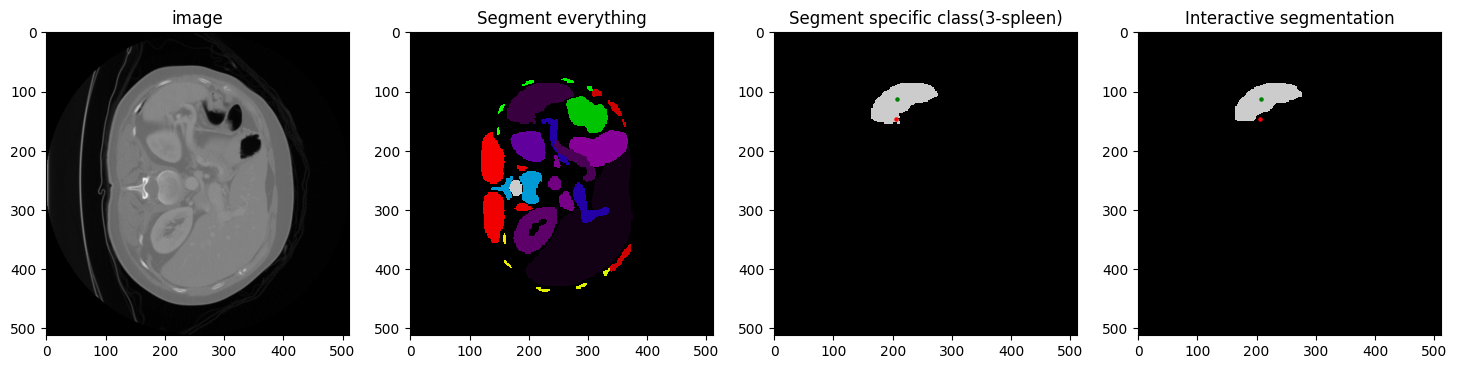

In [20]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
os.chdir("/opt/NV-Segment-CTMR/NV-Segment-CT")
img = "example/spleen_03.nii.gz"
seg0 = "eval/spleen_03/spleen_03_trans0.nii.gz"
seg1 = "eval/spleen_03/spleen_03_trans1.nii.gz"
seg2 = "eval/spleen_03/spleen_03_trans2.nii.gz"
img = nib.load(img).get_fdata()
seg0 = nib.load(seg0).get_fdata()
seg1 = nib.load(seg1).get_fdata()
seg2 = nib.load(seg2).get_fdata()
slice_num = 23
plt.figure("image", (18, 6))

plt.subplot(1, 4, 1)
plt.title("image")
plt.imshow(img[:, :, slice_num], cmap="gray")

plt.subplot(1, 4, 2)
plt.title("Segment everything")
cur_seg=seg0[:, :, slice_num]
plt.imshow(
    cur_seg,
    cmap="nipy_spectral",        
    vmin=0,                       
    vmax=np.max(cur_seg),
    interpolation="nearest"
)


plt.subplot(1, 4, 3)
plt.title("Segment specific class(3-spleen)")
cur_seg=seg1[:, :, slice_num]
cur_seg[cur_seg!=3]=0
plt.imshow(
    cur_seg,
    cmap="nipy_spectral",        
    vmin=0,                       
    vmax=np.max(cur_seg),
    interpolation="nearest"
)
pts_x, pts_y = 206,146
plt.scatter(pts_x, pts_y, s=5, c='red', marker='o',zorder=10)
pts_x, pts_y = 207,113
plt.scatter(pts_x, pts_y, s=5, c='green', marker='o',zorder=10)

plt.subplot(1, 4, 4)
plt.title("Interactive segmentation")
cur_seg=seg2[:, :, slice_num]
cur_seg[cur_seg!=1]=0

plt.imshow(
    cur_seg,
    cmap="nipy_spectral",        
    vmin=0,                       
    vmax=np.max(cur_seg),
    interpolation="nearest"
)
pts_x, pts_y = 206,146
plt.scatter(pts_x, pts_y, s=5, c='red', marker='o',zorder=10)
pts_x, pts_y = 207,113
plt.scatter(pts_x, pts_y, s=5, c='green', marker='o',zorder=10)
plt.show()

## 2. NV-Segment-CTMR
### 2.1 安装
#### 2.1.1 安装MONAI
> 请参考[沐曦GPU运行MONAI 1.5.2说明文档](https://github.com/MetaX-MACA/MedicalImage/blob/main/MONAI/README.md) 安装MONAI  

> 为简化环境部署，后续会在沐曦开发者社区提供`MONAI镜像`，请关注[沐曦开发者|镜像资源中心](https://developer.metax-tech.com/softnova/docker/)获取对应资源。

### 2.1.2 安装其它环境依赖

In [ ]:
%%bash
cd /opt
#git clone https://github.com/NVIDIA-Medtech/NV-Segment-CTMR.git
cp NV-Segment-CTMR/NV-Segment-CTMR/requirements.txt /tmp/
awk '!/torch/' /tmp/requirements.txt > /tmp/tmp && awk '!/monai/' /tmp/tmp > /tmp/requirements.txt
pip install -r /tmp/requirements.txt

### 2.1.3 环境验证：

In [17]:
%%bash
cd /opt/NV-Segment-CTMR
git rev-parse HEAD
python -c "import torch; assert torch.cuda.is_available(); print('PyTorch version:', torch.__version__); print('CUDA OK:', torch.cuda.get_device_name(0))"
python -c "import monai; monai.config.print_config()"

f9f5f51b589e5dc9c23c453cf5138398e4084056
PyTorch version: 2.4.0+metax3.8.0.7
CUDA OK: MetaX C500
MONAI version: 1.4.0+0.g46a52721.dirty
Numpy version: 1.24.4
Pytorch version: 2.4.0+metax3.8.0.7
MONAI flags: HAS_EXT = True, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 46a5272196a6c2590ca2589029eed8e4d56ff008
MONAI __file__: /opt/conda/lib/python3.10/site-packages/monai-1.4.0+0.g46a52721.dirty-py3.10-linux-x86_64.egg/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.6
Nibabel version: 5.2.1
scikit-image version: 0.24.0
scipy version: 1.15.3
Pillow version: 10.4.0
Tensorboard version: 2.13.0
gdown version: 6.1.0
TorchVision version: 0.15.1+metax3.8.0.7
tqdm version: 4.66.2
lmdb version: 2.2.1
psutil version: 7.2.2
pandas version: 2.3.3
einops version: 0.6.1
transformers version: 4.40.2
mlflow version: 3.14.0
pynrrd version: 1.1.3
clearml version: 2.1.9

For details about installing the optional dependencies, please visit:
    https://do

## 2.2 沐曦GPU 运行效果展示
首次运行时，系统会从[Hugging Face](https://huggingface.co/nvidia/NV-Segment-CTMR/tree/main/vista3d_pretrained_model) 下载模型权重并存入本地缓存目录，同时在 models/model.pt 路径建立链接；后续运行将直接复用已缓存的权重，无需重复下载。
>为提升 `Conv3D` 在沐曦 GPU 上的性能,请设置环境变量：export PYTORCH_DEFAULT_NDHWC=1

In [18]:
%%bash
export PYTORCH_DEFAULT_NDHWC=1
cd /opt/NV-Segment-CTMR/NV-Segment-CTMR
# Automatic Segment everything. It requires a modality key. We allow "CT_BODY", "MRI_BODY", and "MRI_BRAIN". For brain, we require preprocessing.
python -m monai.bundle run --config_file configs/inference.json --input_dict "{'image':'example/s0289.nii.gz'}" --modality MRI_BODY --output_postfix trans0
# Automatic Segment specific class
python -m monai.bundle run --config_file configs/inference.json --input_dict "{'image':'example/s0289.nii.gz','label_prompt':[3]}" --output_postfix trans1

2026-08-12 15:17:33,293 - INFO - --- input summary of monai.bundle.scripts.run ---
2026-08-12 15:17:33,294 - INFO - > config_file: 'configs/inference.json'
2026-08-12 15:17:33,294 - INFO - > input_dict: {'image': 'example/s0289.nii.gz'}
2026-08-12 15:17:33,294 - INFO - > modality: 'MRI_BODY'
2026-08-12 15:17:33,294 - INFO - > output_postfix: 'trans0'
2026-08-12 15:17:33,294 - INFO - ---


2026-08-12 15:17:33,294 - INFO - Setting logging properties based on config: configs/logging.conf.
[nvseg] warning: could not touch Hugging Face download counter for nvidia/NV-Segment-CTMR/config.json: (MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /nvidia/NV-Segment-CTMR/resolve/main/config.json (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))"), '(Request ID: 6f32d875-c48e-4085-bcf9-8ac265f8ef7e)')


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


2026-08-12 15:17:40,618 - root - INFO - Restored all variables from .//models/model.pt
2026-08-12 15:17:40,618 - ignite.engine.engine.Vista3dEvaluator - INFO - Engine run resuming from iteration 0, epoch 0 until 1 epochs
2026-08-12 15:17:46,397 INFO image_writer.py:197 - writing: eval/s0289/s0289_trans0.nii.gz
2026-08-12 15:17:46,477 - ignite.engine.engine.Vista3dEvaluator - INFO - Epoch[1] Complete. Time taken: 00:00:05.858
2026-08-12 15:17:46,477 - ignite.engine.engine.Vista3dEvaluator - INFO - Engine run complete. Time taken: 00:00:05.858
2026-08-12 15:17:55,207 - INFO - --- input summary of monai.bundle.scripts.run ---
2026-08-12 15:17:55,207 - INFO - > config_file: 'configs/inference.json'
2026-08-12 15:17:55,207 - INFO - > input_dict: {'image': 'example/s0289.nii.gz', 'label_prompt': [3]}
2026-08-12 15:17:55,207 - INFO - > output_postfix: 'trans1'
2026-08-12 15:17:55,207 - INFO - ---


2026-08-12 15:17:55,207 - INFO - Setting logging properties based on config: configs/logging.co

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


2026-08-12 15:18:02,467 - root - INFO - Restored all variables from .//models/model.pt
2026-08-12 15:18:02,468 - ignite.engine.engine.Vista3dEvaluator - INFO - Engine run resuming from iteration 0, epoch 0 until 1 epochs
2026-08-12 15:18:08,001 INFO image_writer.py:197 - writing: eval/s0289/s0289_trans1.nii.gz
2026-08-12 15:18:08,075 - ignite.engine.engine.Vista3dEvaluator - INFO - Epoch[1] Complete. Time taken: 00:00:05.607
2026-08-12 15:18:08,075 - ignite.engine.engine.Vista3dEvaluator - INFO - Engine run complete. Time taken: 00:00:05.607


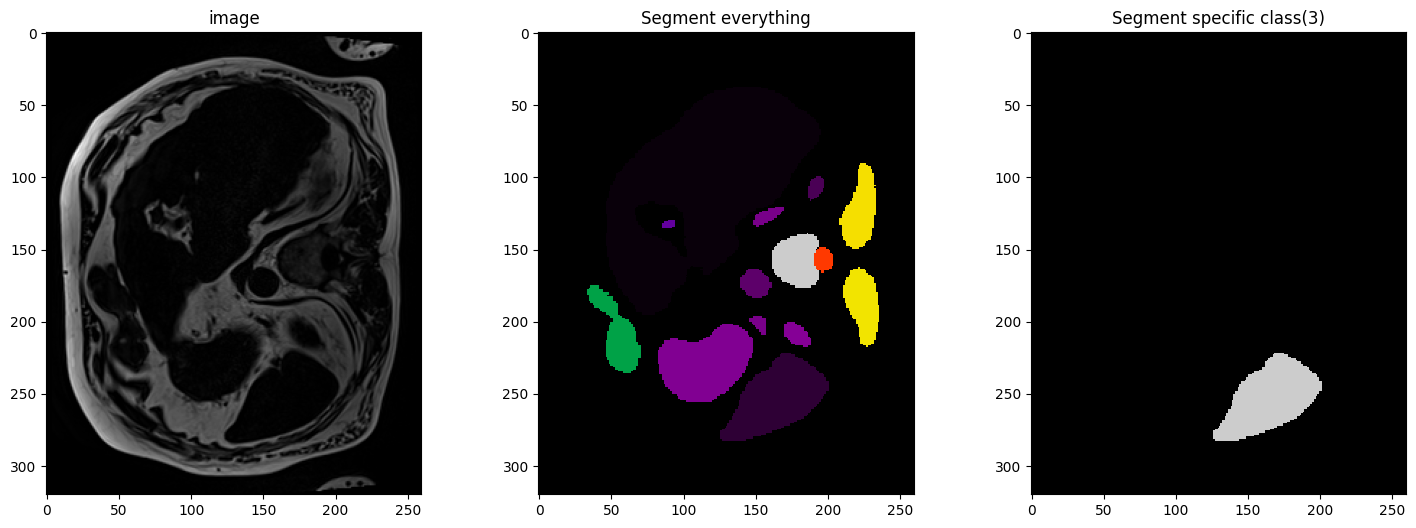

In [21]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
os.chdir("/opt/NV-Segment-CTMR/NV-Segment-CTMR")
img = "example/s0289.nii.gz"
seg0 = "eval/s0289/s0289_trans0.nii.gz"
seg1 = "eval/s0289/s0289_trans1.nii.gz"
img = nib.load(img).get_fdata()
seg0 = nib.load(seg0).get_fdata()
seg1 = nib.load(seg1).get_fdata()
slice_num = seg0.shape[-1]//2
plt.figure("image", (18, 6))

plt.subplot(1, 3, 1)
plt.title("image")
plt.imshow(img[:, :, slice_num], cmap="gray")

plt.subplot(1, 3, 2)
plt.title("Segment everything")
cur_seg=seg0[:, :, slice_num]
plt.imshow(
    cur_seg,
    cmap="nipy_spectral",        
    vmin=0,                       
    vmax=np.max(cur_seg),
    interpolation="nearest"
)

plt.subplot(1, 3, 3)
plt.title("Segment specific class(3)")
cur_seg=seg1[:, :, slice_num]
cur_seg[cur_seg!=3]=0
plt.imshow(
    cur_seg,
    cmap="nipy_spectral",        
    vmin=0,                       
    vmax=np.max(cur_seg),
    interpolation="nearest"
)
plt.show()

---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。

### Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.